In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.data_loader import load_data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import LSTM, Dense

In [4]:
data = load_data("../data/nifty50_processed.csv")

data = data.dropna()
data.head()


,Close,High,Low,Open,Volume,returns,volatility
Date,,,,,,,
2015-02-03,8756.549805,8837.299805,8726.650391,8823.150391,208700,-0.004654,0.011485
2015-02-04,8723.700195,8792.849609,8704.400391,8789.150391,195300,-0.003758,0.011521
2015-02-05,8711.700195,8838.450195,8683.650391,8733.099609,173600,-0.001377,0.008886
2015-02-06,8661.049805,8726.200195,8645.549805,8696.849609,171300,-0.005831,0.009004
2015-02-09,8526.349609,8605.549805,8516.349609,8584.400391,146800,-0.015675,0.009376


In [5]:
# Use volatility
dataset = data[['volatility']].values

# Normalize
scaler = MinMaxScaler(feature_range=(0,1))
dataset_scaled = scaler.fit_transform(dataset)


In [19]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i][0])
    return np.array(X), np.array(y)

seq_length = 20  # past 20 days

X, y = create_sequences(dataset_scaled, seq_length)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2418, 20, 1)
y shape: (2418,)


In [20]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [21]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/Users/divyanshsingh/volatility-forecasting/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0037 - val_loss: 9.5825e-04
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_loss: 9.7556e-04
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.4492e-04 - val_loss: 7.6614e-04
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2887e-04 - val_loss: 6.7264e-04
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.5494e-04 - val_loss: 6.6983e-04
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.2828e-04 - val_loss: 6.7474e-04
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.0881e-04 - val_loss: 6.0150e-04
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.9055e-04 - val_loss: 6.6098e-04
Epoch 9/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.8760e-04 - val_loss: 5.6090e-04
Epoch 10/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.6330e-04 - val_loss: 5.2163e-04


In [23]:
predictions = model.predict(X_test)

# Inverse scaling
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


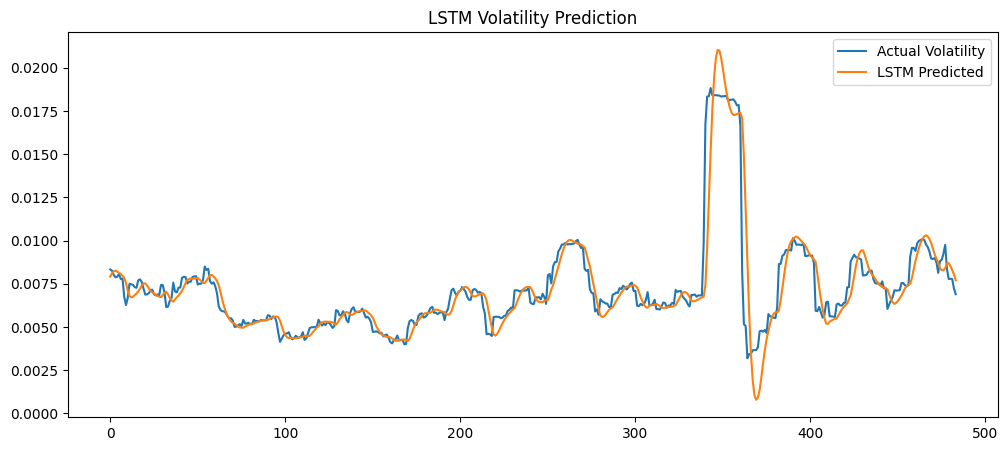

In [24]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual Volatility')
plt.plot(predictions, label='LSTM Predicted')
plt.legend()
plt.title("LSTM Volatility Prediction")
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("LSTM RMSE:", rmse)


LSTM RMSE: 0.0012618267359007453


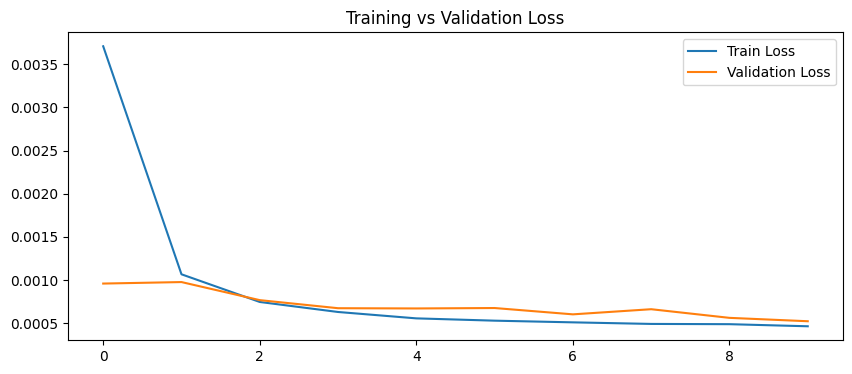

In [25]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [26]:
data['lstm_pred'] = np.nan
data.loc[data.index[-len(predictions):], 'lstm_pred'] = predictions.flatten()

data[['volatility', 'lstm_pred']].to_csv('../results/lstm_results.csv')